# Gap scan post-processing (JUAS2 NC Dipole)
This notebook reads the FEMM-exported `gap_By_scan.csv`, plots **By(x)** and **ΔBy/By0**, and computes a few basic field-quality metrics.

**Input:** `../data/gap_By_scan.csv` (move the file there after running FEMM)

See `../TODO.md` for the full analysis checklist inspired by the JUAS FEMM tutorial (field sanity checks, saturation checks, operation range, GFR boundary, etc.).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path('..') / 'data' / 'gap_By_scan.csv'
assert DATA_PATH.exists(), f"CSV not found: {DATA_PATH.resolve()}"

df = pd.read_csv(DATA_PATH)
df.head()

,x_mm,y_mm,Bx_T,By_T,Bmag_T,dBy_over_By0
0,-77.600,12.5,-0.121145,-0.552469,0.565595,-0.114675
1,-77.212,12.5,-0.118262,-0.556235,0.568668,-0.108640
2,-76.824,12.5,-0.115379,-0.560001,0.571764,-0.102605
3,-76.436,12.5,-0.112496,-0.563767,0.574882,-0.096569
4,-76.048,12.5,-0.109613,-0.567533,0.578022,-0.090534


In [3]:
# Basic sanity checks
required_cols = {'x_mm','y_mm','Bx_T','By_T','Bmag_T','dBy_over_By0'}
missing = required_cols - set(df.columns)
assert not missing, f"Missing columns: {missing}"

# Ensure sorted by x
if not df['x_mm'].is_monotonic_increasing:
    df = df.sort_values('x_mm').reset_index(drop=True)

x = df['x_mm'].to_numpy()
By = df['By_T'].to_numpy()

print(f"N={len(df)} points")
print(f"x range: [{x.min():.3f}, {x.max():.3f}] mm")
print(f"scan y: {df['y_mm'].iloc[0]:.3f} mm (assumed constant)")
print(f"By@x=0 (nearest sample): {By[np.argmin(np.abs(x))]:.6g} T")

N=401 points
x range: [-77.600, 77.600] mm
scan y: 12.500 mm (assumed constant)
By@x=0 (nearest sample): -0.624029 T


In [4]:
# Recompute By0 and ΔBy/By0 robustly
# FEMM export uses By0 sampled at (0, scan_y). Here we recompute it using interpolation.
By0 = np.interp(0.0, x, By)
if abs(By0) < 1e-30:
    By0 = 1e-30

hom = By/By0 - 1.0

# Compare to CSV column (small diffs are expected if x=0 is not exactly on the grid)
hom_csv = df['dBy_over_By0'].to_numpy()
max_diff = np.max(np.abs(hom - hom_csv))
print(f"Interpolated By0 = {By0:.6g} T")
print(f"max |hom - hom_csv| = {max_diff:.3e}")

Interpolated By0 = -0.624029 T
max |hom - hom_csv| = 3.153e-16


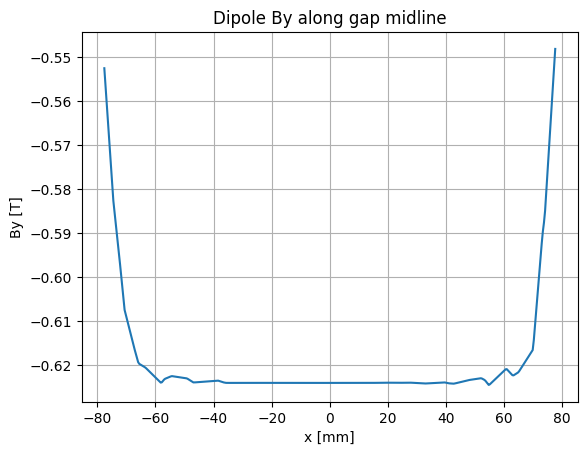

In [5]:
# Plot By(x)
plt.figure()
plt.plot(x, By)
plt.xlabel('x [mm]')
plt.ylabel('By [T]')
plt.grid(True)
plt.title('Dipole By along gap midline')
plt.show()

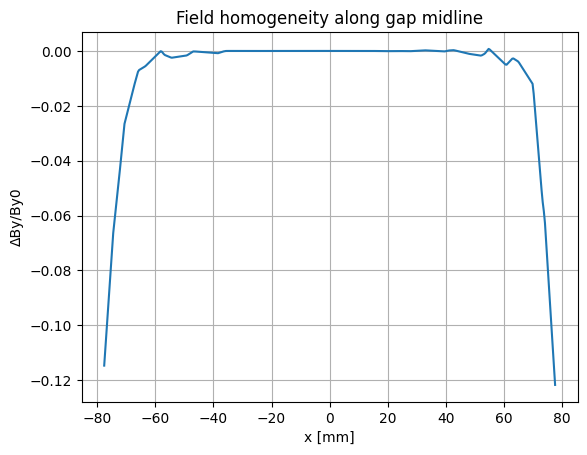

In [6]:
# Plot homogeneity ΔBy/By0
plt.figure()
plt.plot(x, hom)
plt.xlabel('x [mm]')
plt.ylabel('ΔBy/By0')
plt.grid(True)
plt.title('Field homogeneity along gap midline')
plt.show()

In [7]:
# Basic field quality metrics in a chosen Good Field Region (GFR)
# Edit these bounds for your spec (case study typically defines a required GFR width).
GFR_X_MM = 40.0  # half-width of GFR in mm (CHANGE ME)

mask = (x >= -GFR_X_MM) & (x <= GFR_X_MM)

hom_gfr = hom[mask]
x_gfr = x[mask]

max_abs = np.max(np.abs(hom_gfr))
rms = np.sqrt(np.mean(hom_gfr**2))

# Flat-top width for a given spec
SPEC = 1e-3  # e.g. 1e-3 = 0.1% (CHANGE ME)
mask_spec = np.abs(hom) <= SPEC

# longest contiguous segment around x=0 that meets spec
# (simple approach: start from nearest-to-zero index and expand while spec holds)
idx0 = int(np.argmin(np.abs(x)))
L = idx0
R = idx0
while L-1 >= 0 and mask_spec[L-1]:
    L -= 1
while R+1 < len(x) and mask_spec[R+1]:
    R += 1
flat_width = x[R] - x[L]

print(f"GFR half-width: ±{GFR_X_MM} mm")
print(f"max |ΔBy/By0| in GFR: {max_abs:.3e}")
print(f"RMS(ΔBy/By0) in GFR: {rms:.3e}")
print(f"Spec threshold: |ΔBy/By0| <= {SPEC:.3e}")
print(f"Flat-top width around x=0 meeting spec: {flat_width:.3f} mm")

GFR half-width: ±40.0 mm
max |ΔBy/By0| in GFR: 8.247e-04
RMS(ΔBy/By0) in GFR: 1.500e-04
Spec threshold: |ΔBy/By0| <= 1.000e-03
Flat-top width around x=0 meeting spec: 95.448 mm


Saved figures to /Users/leogrossman/Desktop/JUAS26-Course2-NC-Mag-Case-Study/figures


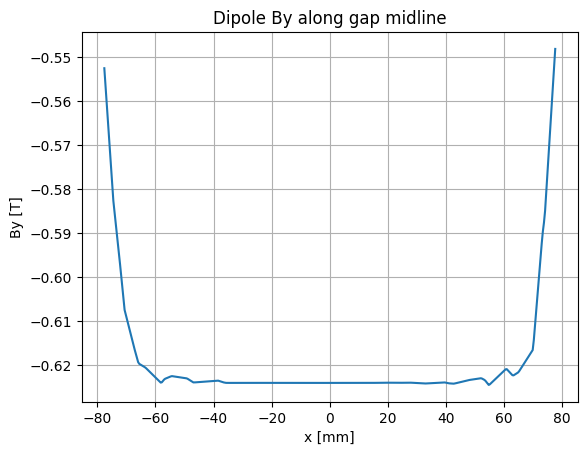

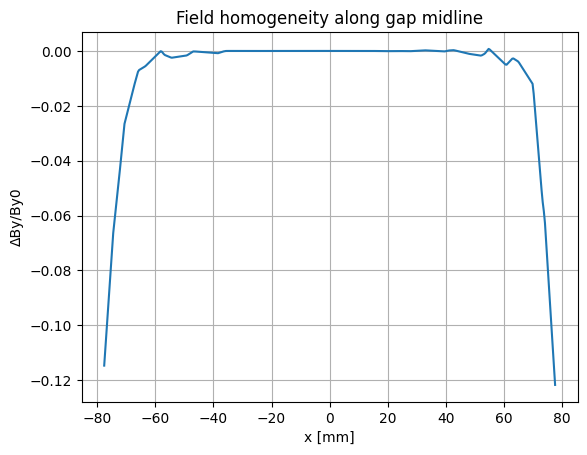

In [10]:
# Optional: save figures (uncomment to enable)
outdir = Path('..') / 'figures'
outdir.mkdir(exist_ok=True)

plt.figure(); plt.plot(x, By); plt.xlabel('x [mm]'); plt.ylabel('By [T]'); plt.grid(True)
plt.title('Dipole By along gap midline');
plt.savefig(outdir / 'By_vs_x.png', dpi=200, bbox_inches='tight')

plt.figure(); plt.plot(x, hom); plt.xlabel('x [mm]'); plt.ylabel('ΔBy/By0'); plt.grid(True)
plt.title('Field homogeneity along gap midline');
plt.savefig(outdir / 'dBy_over_By0_vs_x.png', dpi=200, bbox_inches='tight')

print('Saved figures to', outdir.resolve())

In [11]:
# Optional: export a one-line summary for report tables
summary = {
    'scan_y_mm': float(df['y_mm'].iloc[0]),
    'By0_T': float(By0),
    'GFR_halfwidth_mm': float(GFR_X_MM),
    'max_abs_dBy_over_By0_GFR': float(max_abs),
    'rms_dBy_over_By0_GFR': float(rms),
    'spec_threshold': float(SPEC),
    'flat_top_width_mm': float(flat_width),
}
pd.DataFrame([summary]).to_csv(Path('..')/'data'/'gap_scan_summary.csv', index=False)
summary

{'scan_y_mm': 12.5,
 'By0_T': -0.6240294613522029,
 'GFR_halfwidth_mm': 40.0,
 'max_abs_dBy_over_By0_GFR': 0.0008246688949522518,
 'rms_dBy_over_By0_GFR': 0.00015002213488422435,
 'spec_threshold': 0.001,
 'flat_top_width_mm': 95.44799999999998}